# Newsgroups20: Extraccion de Topics con Etiquetas Padre

Este notebook analiza la estructura de topics del dataset completo Newsgroups20 (18,262 documentos, 20 etiquetas)
agrupando en **7 etiquetas padre**:

- **comp** (5 sublabels): graphics, os.ms-windows.misc, sys.ibm.pc.hardware, sys.mac.hardware, windows.x
- **rec** (4 sublabels): autos, motorcycles, sport.baseball, sport.hockey
- **sci** (4 sublabels): crypt, electronics, med, space
- **talk** (4 sublabels): politics.guns, politics.mideast, politics.misc, religion.misc
- **soc** (1 sublabel): religion.christian
- **misc** (1 sublabel): forsake
- **alt** (1 sublabel): atheism

Se comparan dos configuraciones NMF:
1. TF-IDF + NMF (Frobenius)
2. BoW + NMF (KL divergence)

Evaluacion:
- Cuantitativa: NMI, ARI, confianza media, entropia de asignacion y error de reconstruccion.
- Cualitativa: terminos por topico, documentos representativos y distribucion de etiquetas por topico.


In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.feature_extraction import text as sklearn_text
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_colwidth", 200)

In [2]:
# Resolver root del repo y rutas de entrada/salida
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation").exists()),
        CANDIDATE_ROOT,
    )

EDA_TABLES = ROOT / "validation" / "results" / "newsgroups20_eda" / "tables"
UMAP_ROOT = ROOT / "validation" / "results" / "newsgroups20_umap"
CACHE_DIR = UMAP_ROOT / "cache"

RESULTS_DIR = ROOT / "validation" / "results" / "newsgroups20_topic_extraction"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
for p in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

subset_path = EDA_TABLES / "newsgroups20_topic8_subset.csv"
if not subset_path.exists():
    raise FileNotFoundError(f"No se encontro el subset: {subset_path}")

print(f"ROOT: {ROOT}")
print(f"Subset: {subset_path}")
print(f"Cache embeddings: {CACHE_DIR}")
print(f"Resultados: {RESULTS_DIR}")

ROOT: /home/gabrielsanchez/repos/TFG-Chatbot
Subset: /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset.csv
Cache embeddings: /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_umap/cache
Resultados: /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction


In [3]:
# Carga del dataset completo y extraccion de etiquetas padre
full_path = EDA_TABLES / "newsgroups20_all_documents.csv"
if not full_path.exists():
    raise FileNotFoundError(f"No se encontro el dataset completo: {full_path}")

df = pd.read_csv(full_path)
if "text" not in df.columns:
    if "document" in df.columns:
        df = df.rename(columns={"document": "text"})
    else:
        raise ValueError("El dataset no contiene columna 'text' ni 'document'.")

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str)
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)

# --- Extraer etiqueta padre ---
# Labels originales: comp.graphics, rec.sport.baseball, sci.crypt, talk.politics.guns, ...
# Etiquetas padre: comp, rec, sci, talk, soc, misc, alt
def extract_parent_label(label: str) -> str:
    """Extrae la categoria padre del label original.
    
    Ejemplos:
        comp.graphics -> comp
        rec.sport.baseball -> rec
        sci.crypt -> sci
        talk.politics.guns -> talk
    """
    parts = label.split('.')
    return parts[0] if len(parts) >= 2 else label

df["parent_label"] = df["label"].map(extract_parent_label)

# --- Funcion de limpieza de texto ---
def clean_newsgroup_text(raw: str) -> str:
    # Filtra lineas con baja proporcion alfabetica (tipico de bloques codificados/ruido).
    kept_lines = []
    for line in raw.splitlines():
        s = line.strip()
        if not s:
            continue
        alpha = sum(ch.isalpha() for ch in s)
        alnum = sum(ch.isalnum() for ch in s)
        if alnum > 0 and (alpha / alnum) < 0.55:
            continue
        kept_lines.append(s)

    text = " ".join(kept_lines)
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)
    text = re.sub(r"[_`~^|\\/=+*#<>$%&{}\[\]\(\)-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    # Mantiene alineacion con embeddings cacheados aunque el texto quede casi vacio.
    return text if text else "emptydoc"

df["text_clean"] = df["text"].map(clean_newsgroup_text)

# Usar parent_label como ground truth para la evaluacion
texts = df["text"].tolist()
texts_clean = df["text_clean"].tolist()
labels_original = df["label"].tolist()
labels_parent = df["parent_label"].tolist()

# Estadisticas del dataset
print(f"Documentos: {len(df)}")
print(f"Etiquetas originales: {df['label'].nunique()}")
print(f"Etiquetas padre: {df['parent_label'].nunique()}")
print(f"\nDistribucion por etiqueta padre:")
for label, count in df['parent_label'].value_counts().items():
    print(f"  {label}: {count:5d} ({count/len(df)*100:.1f}%)")
print(f"\nEjemplo de limpieza (original -> clean):")
print(df.loc[0, "text"][:180])
print("---")
print(df.loc[0, "text_clean"][:180])
print(f"\nEjemplo de etiqueta: {df.loc[0, 'label']} -> {df.loc[0, 'parent_label']}")
display(df.head(3)[['label', 'parent_label', 'text_clean']].head(3))


Documentos: 18262
Etiquetas originales: 20
Etiquetas padre: 7

Distribucion por etiqueta padre:
  comp:  4744 (26.0%)
  rec:  3834 (21.0%)
  sci:  3825 (20.9%)
  talk:  3163 (17.3%)
  soc:   974 (5.3%)
  misc:   943 (5.2%)
  alt:   779 (4.3%)

Ejemplo de limpieza (original -> clean):
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Brick
---
i was wondering if anyone out there could enlighten me on this car i saw the other day. it was a 2 door sports car, looked to be from the late 60s early 70s. it was called a brickl

Ejemplo de etiqueta: rec.autos -> rec


,label,parent_label,text_clean
0,rec.autos,rec,"i was wondering if anyone out there could enlighten me on this car i saw the other day. it was a 2 door sports car, looked to be from the late 60s early 70s. it was called a bricklin. the doors we..."
1,comp.sys.mac.hardware,comp,a fair number of brave souls who upgraded their si clock oscillator have shared their experiences for this poll. please send a brief message detailing your experiences with the procedure. top spee...
2,comp.sys.mac.hardware,comp,"well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a bit sooner than i intended to be... i'm l..."


In [4]:
# Construccion de matrices textuales sobre texto limpio
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-z][a-z]{2,}\b",
    max_features=7000,
    ngram_range=(1, 2),
    min_df=4,
    max_df=0.85,
    sublinear_tf=True,
    strip_accents="unicode",
)

# Stopwords extra detectadas en tokens ruidosos del subset tecnico.
extra_noise_stopwords = {"max", "bhj", "bxn", "chz", "giz", "qax", "biz"}
bow_stop_words = sorted(sklearn_text.ENGLISH_STOP_WORDS.union(extra_noise_stopwords))

bow_vectorizer = CountVectorizer(
    stop_words=bow_stop_words,
    token_pattern=r"(?u)\b[a-z][a-z]{2,}\b",
    max_features=7000,
    ngram_range=(1, 1),
    min_df=4,
    max_df=0.85,
    strip_accents="unicode",
)

X_tfidf = tfidf_vectorizer.fit_transform(texts_clean)
X_bow = bow_vectorizer.fit_transform(texts_clean)

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"BoW shape: {X_bow.shape}")
print("Top 20 terminos BoW tras limpieza:")
bow_freq = np.asarray(X_bow.sum(axis=0)).ravel()
top_idx = np.argsort(bow_freq)[::-1][:20]
print(bow_vectorizer.get_feature_names_out()[top_idx].tolist())

TF-IDF shape: (18262, 7000)
BoW shape: (18262, 7000)
Top 20 terminos BoW tras limpieza:
['like', 'don', 'people', 'just', 'know', 'use', 'think', 'time', 'does', 'new', 'good', 'god', 'way', 'make', 'used', 'say', 'right', 'did', 'want', 'said']


## Definicion de utilidades de evaluacion

In [5]:
def dominant_topic_distribution(W: np.ndarray) -> pd.Series:
    dominant = W.argmax(axis=1)
    return pd.Series(dominant).value_counts(normalize=True).sort_index()


def normalized_entropy(probs: np.ndarray) -> float:
    probs = probs[probs > 0]
    if probs.size == 0:
        return 0.0
    h = -np.sum(probs * np.log(probs))
    h_max = np.log(len(probs))
    return float(h / h_max) if h_max > 0 else 0.0


def topic_diversity(terms_per_topic: list[list[str]]) -> float:
    flat = [t for topic in terms_per_topic for t in topic]
    if not flat:
        return np.nan
    return float(len(set(flat)) / len(flat))


def term_coherence_umass(X_counts, topics_idx: list[np.ndarray], eps: float = 1.0) -> float:
    # Coherencia aproximada tipo UMass sobre matriz de coocurrencia binaria
    X_bin = (X_counts > 0).astype(int).tocsr()
    df_term = np.asarray(X_bin.sum(axis=0)).ravel()
    cooc = (X_bin.T @ X_bin).toarray()

    topic_scores = []
    for idx in topics_idx:
        pairs = 0
        score = 0.0
        for i in range(1, len(idx)):
            wi = idx[i]
            for j in range(i):
                wj = idx[j]
                pairs += 1
                score += np.log((cooc[wi, wj] + eps) / max(df_term[wj], 1))
        if pairs > 0:
            topic_scores.append(score / pairs)
    if not topic_scores:
        return np.nan
    return float(np.mean(topic_scores))


def get_top_terms(H: np.ndarray, feature_names: np.ndarray, top_n: int = 10) -> tuple[list[list[str]], list[np.ndarray]]:
    topics_terms = []
    topics_idx = []
    for comp in H:
        idx = np.argsort(comp)[::-1][:top_n]
        topics_idx.append(idx)
        topics_terms.append(feature_names[idx].tolist())
    return topics_terms, topics_idx

## Ejecucion de experimentos

In [6]:
# ============================================================
# Ejecucion de experimentos con etiquetas PADRE
# ============================================================

# k_values incluye 7 (numero de categorias padre) + valores vecinos
k_values = [5, 7, 10, 12]
random_state = 42

# Usar labels_parent como ground truth para NMI/ARI
labels = labels_parent 
label_codes = pd.Categorical(labels).codes

print(f"Ground truth: {len(set(labels))} etiquetas padre")
print(f"Etiquetas padre: {sorted(set(labels))}")

configs: list[dict[str, Any]] = [
    {
        "name": "tfidf_nmf_fro",
        "X": X_tfidf,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "cd",
        "beta_loss": "frobenius",
        "feature_names": np.array(tfidf_vectorizer.get_feature_names_out()),
        "counts_for_coherence": X_bow,
    },
    {
        "name": "bow_nmf_kl",
        "X": X_bow,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "mu",
        "beta_loss": "kullback-leibler",
        "feature_names": np.array(bow_vectorizer.get_feature_names_out()),
        "counts_for_coherence": X_bow,
    },
]

rows = []
topic_terms_records = []
doc_assignments = []

for cfg in configs:
    for k in k_values:
        model = NMF(
            n_components=k,
            init="nndsvda",
            random_state=random_state,
            max_iter=800,
            solver=cfg["solver"],
            beta_loss=cfg["beta_loss"],
            alpha_W=cfg["alpha"],
            alpha_H=cfg["alpha"],
            l1_ratio=cfg["l1_ratio"],
        )

        W = model.fit_transform(cfg["X"])
        H = model.components_
        dominant_topic = W.argmax(axis=1)

        topic_mass = dominant_topic_distribution(W)
        topic_entropy = normalized_entropy(topic_mass.values)
        confidence = float(np.mean(W.max(axis=1) / np.clip(W.sum(axis=1), 1e-12, None)))

        row = {
            "model": cfg["name"],
            "k": k,
            "nmi": float(normalized_mutual_info_score(labels, dominant_topic)),
            "ari": float(adjusted_rand_score(labels, dominant_topic)),
            "avg_topic_confidence": confidence,
            "topic_entropy": topic_entropy,
            "reconstruction_err": float(np.linalg.norm(cfg["X"] - W @ H, "fro") ** 2),
        }

        # Coherencia UMass y diversidad de terminos solo para modelos textuales
        if cfg["feature_names"] is not None and cfg["counts_for_coherence"] is not None:
            terms, idx = get_top_terms(H, cfg["feature_names"])
            row["topic_diversity"] = topic_diversity(terms)
            row["coherence_umass"] = term_coherence_umass(cfg["counts_for_coherence"], idx)
        else:
            row["topic_diversity"] = np.nan
            row["coherence_umass"] = np.nan

        rows.append(row)

        # Guardar terminos por topico
        if cfg["feature_names"] is not None:
            for topic_id, top_terms in enumerate(terms):
                topic_terms_records.append({
                    "model": cfg["name"],
                    "k": k,
                    "topic": topic_id,
                    "top_terms": top_terms,
                })

        # Guardar asignaciones de documentos
        doc_assignments.append(pd.DataFrame({
            "model": cfg["name"],
            "k": k,
            "doc_index": np.arange(len(df)),
            "topic": dominant_topic,
            "topic_weight": W.max(axis=1),
            "text": texts,
            "label_original": labels_original,  # etiquetas originales
            "label_parent": labels,  # etiquetas padre
        }))

results_df = pd.DataFrame(rows)
terms_df = pd.DataFrame(topic_terms_records)
assign_df = pd.concat(doc_assignments, ignore_index=True)

print(f"Resultados: {len(results_df)} combinaciones modelo-k")
print(f"Modelos: {results_df['model'].unique().tolist()}")
print(f"\nMejores resultados por modelo:")
display(results_df.sort_values(["model", "nmi"], ascending=[True, False]).groupby("model", as_index=False).first())


Ground truth: 7 etiquetas padre
Etiquetas padre: ['alt', 'comp', 'misc', 'rec', 'sci', 'soc', 'talk']
Resultados: 8 combinaciones modelo-k
Modelos: ['tfidf_nmf_fro', 'bow_nmf_kl']

Mejores resultados por modelo:


,model,k,nmi,ari,avg_topic_confidence,topic_entropy,reconstruction_err,topic_diversity,coherence_umass
0,bow_nmf_kl,5,0.371926,0.291454,0.748213,0.946842,5.316572e+06,0.84,-1.648251
1,tfidf_nmf_fro,10,0.329561,0.220566,0.554014,0.931666,1.747012e+04,0.94,-3.294466


In [7]:
# Resumen del mejor k por modelo segun NMI
best_by_model = results_df.sort_values(["model", "nmi"], ascending=[True, False]).groupby("model", as_index=False).first()
best_by_model.to_csv(TABLES_DIR / "topic_extraction_best_by_model.csv", index=False, encoding="utf-8")
display(best_by_model)

,model,k,nmi,ari,avg_topic_confidence,topic_entropy,reconstruction_err,topic_diversity,coherence_umass
0,bow_nmf_kl,5,0.371926,0.291454,0.748213,0.946842,5.316572e+06,0.84,-1.648251
1,tfidf_nmf_fro,10,0.329561,0.220566,0.554014,0.931666,1.747012e+04,0.94,-3.294466


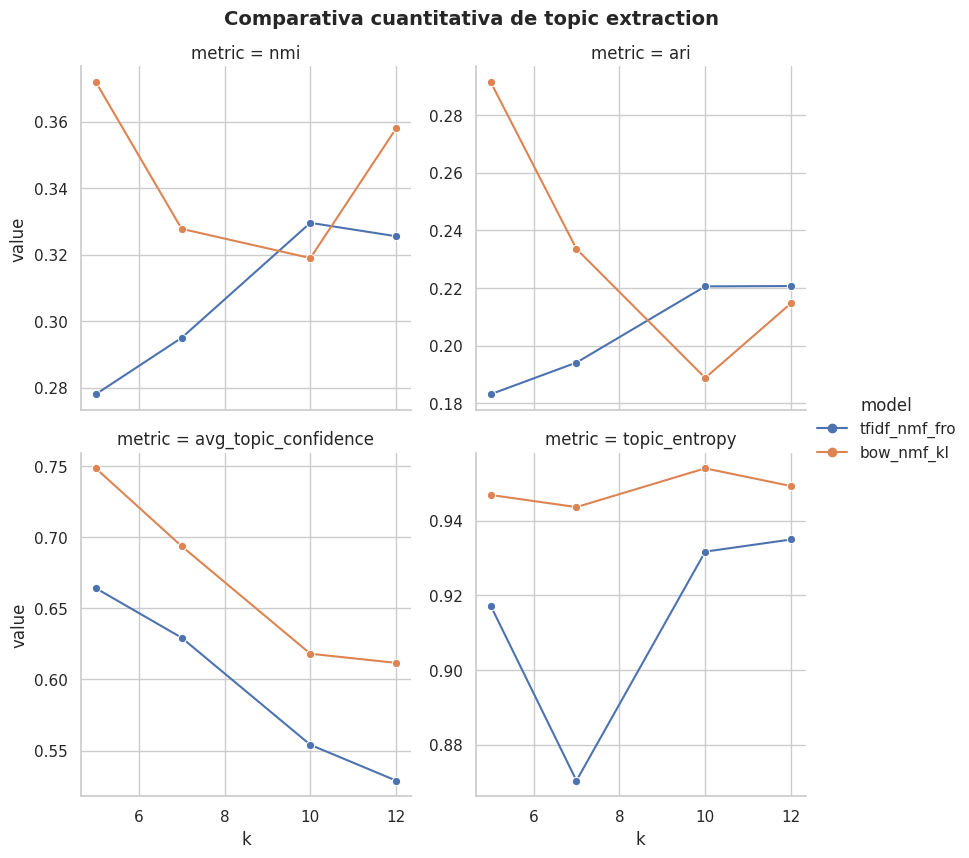

In [8]:
# Visualizacion cuantitativa principal (NMI y ARI)
plot_df = results_df.melt(
    id_vars=["model", "k"],
    value_vars=["nmi", "ari", "avg_topic_confidence", "topic_entropy"],
    var_name="metric",
    value_name="value",
)

g = sns.relplot(
    data=plot_df,
    x="k",
    y="value",
    hue="model",
    col="metric",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4.2,
    facet_kws={"sharey": False},
)
g.fig.suptitle("Comparativa cuantitativa de topic extraction", y=1.02, fontsize=14, fontweight="bold")
g.savefig(FIGURES_DIR / "topic_extraction_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

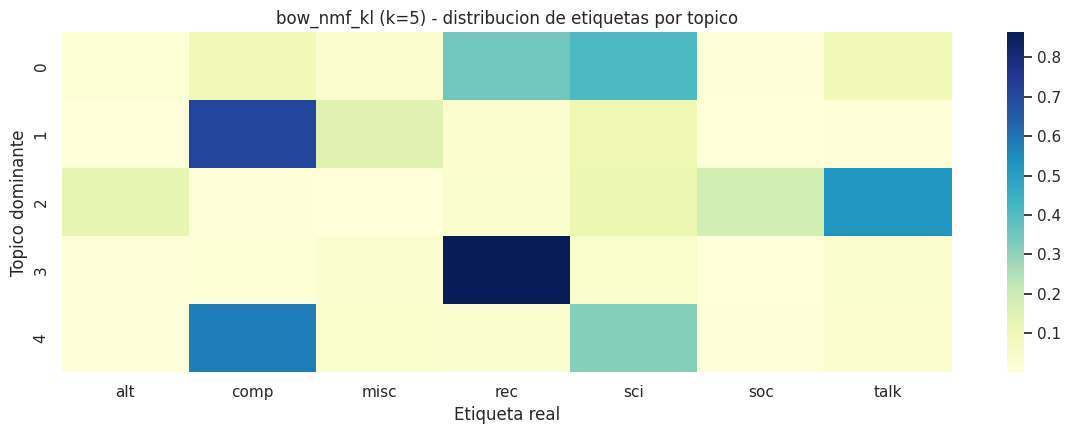

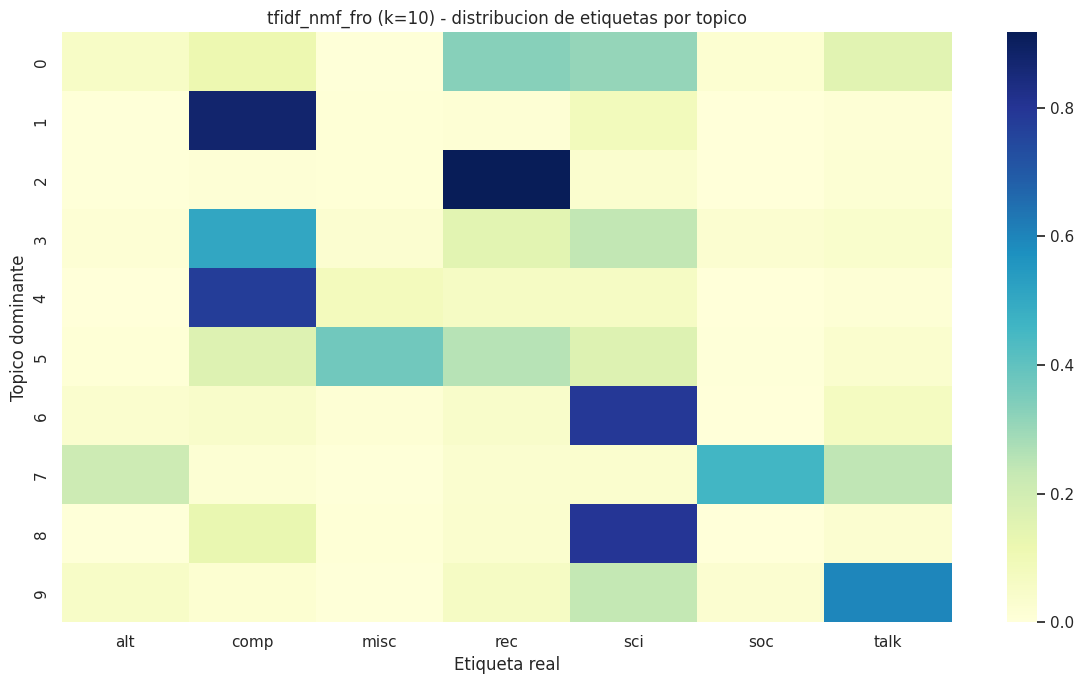

In [9]:
# Heatmaps modelo-topico-etiqueta para el mejor k de cada modelo
for _, row in best_by_model.iterrows():
    model_name = row["model"]
    best_k = int(row["k"])
    slice_df = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == best_k)].copy()

    ctab = pd.crosstab(slice_df["topic"], slice_df["label_parent"], normalize="index")
    ctab.to_csv(TABLES_DIR / f"topic_label_distribution_{model_name}_k{best_k}.csv", encoding="utf-8")

    fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * ctab.shape[0] + 2)))
    sns.heatmap(ctab, cmap="YlGnBu", ax=ax)
    ax.set_title(f"{model_name} (k={best_k}) - distribucion de etiquetas por topico")
    ax.set_xlabel("Etiqueta real")
    ax.set_ylabel("Topico dominante")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"topic_label_heatmap_{model_name}_k{best_k}.png", dpi=180, bbox_inches="tight")
    plt.show()

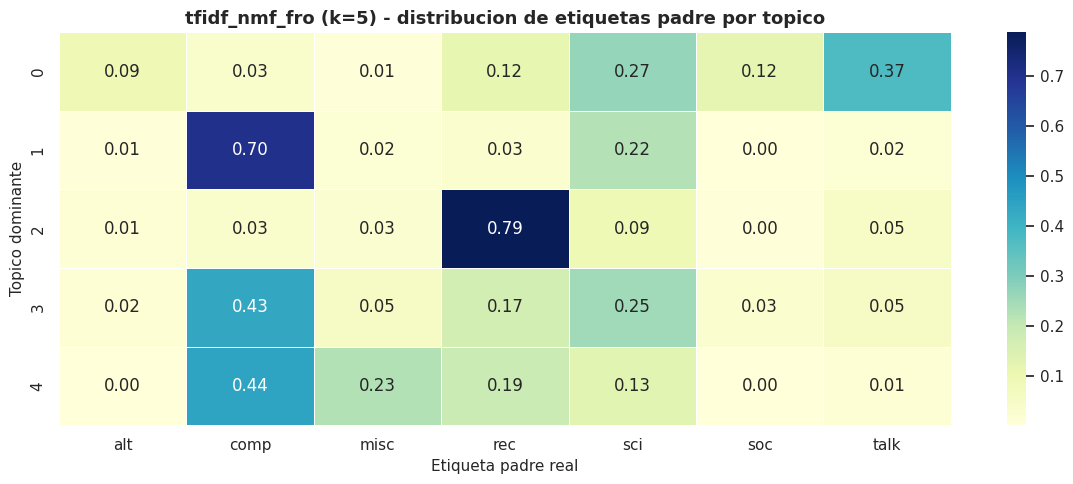

tfidf_nmf_fro k=5: heatmap guardado en /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/figures/topic_label_heatmap_tfidf_nmf_fro_k5.png


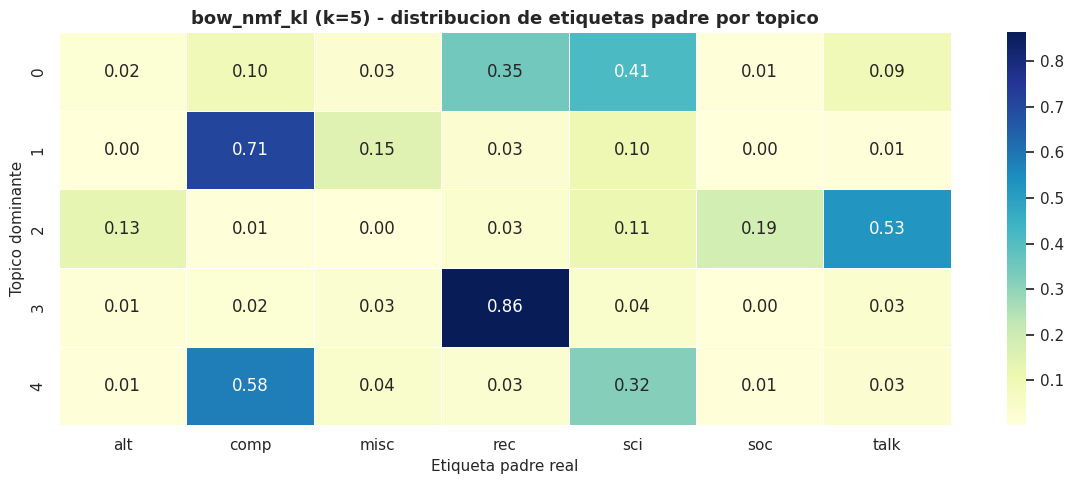

bow_nmf_kl k=5: heatmap guardado en /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/figures/topic_label_heatmap_bow_nmf_kl_k5.png


In [21]:
# Heatmaps modelo-topico-etiqueta para k=7 con cada representacion
k_target = 5

for cfg in configs:
    model_name = cfg["name"]
    slice_df = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == k_target)].copy()

    if slice_df.empty:
        print(f"{model_name} k={k_target}: no hay datos (reexecutar experimentos con k={k_target})")
        continue

    ctab = pd.crosstab(slice_df["topic"], slice_df["label_parent"], normalize="index")
    ctab.to_csv(TABLES_DIR / f"topic_label_distribution_{model_name}_k{k_target}.csv", encoding="utf-8")

    fig, ax = plt.subplots(figsize=(12, max(5, 0.6 * ctab.shape[0] + 2)))
    sns.heatmap(ctab, cmap="YlGnBu", ax=ax, annot=True, fmt=".2f", linewidths=0.5)
    ax.set_title(f"{model_name} (k={k_target}) - distribucion de etiquetas padre por topico", fontsize=13, fontweight="bold")
    ax.set_xlabel("Etiqueta padre real", fontsize=11)
    ax.set_ylabel("Topico dominante", fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"topic_label_heatmap_{model_name}_k{k_target}.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"{model_name} k={k_target}: heatmap guardado en {FIGURES_DIR / f'topic_label_heatmap_{model_name}_k{k_target}.png'}")

## Validacion cualitativa

In [10]:
# Topicos con terminos (solo modelos textuales)
if terms_df.empty:
    print("No hay modelos con terminos interpretables.")
else:
    for _, row in best_by_model.iterrows():
        model_name = row["model"]
        best_k = int(row["k"])
        subset_terms = terms_df[(terms_df["model"] == model_name) & (terms_df["k"] == best_k)]
        if subset_terms.empty:
            continue
        print("=" * 90)
        print(f"Modelo: {model_name} | k={best_k} | top terms por topico")
        print("=" * 90)
        display(subset_terms[["topic", "top_terms"]].sort_values("topic"))

Modelo: bow_nmf_kl | k=5 | top terms por topico


,topic,top_terms
34,0,"[don, like, just, know, think, good, time, use, people, really]"
35,1,"[windows, dos, drive, thanks, use, card, know, does, disk, mac]"
36,2,"[people, god, said, think, don, did, say, know, believe, does]"
37,3,"[game, year, team, games, play, season, win, hockey, players, league]"
38,4,"[file, space, available, use, information, program, image, data, ftp, mail]"


Modelo: tfidf_nmf_fro | k=10 | top terms por topico


,topic,top_terms
12,0,"[don, just, like, think, know, good, really, want, people, sure]"
13,1,"[windows, file, dos, program, files, using, window, use, version, run]"
14,2,"[game, team, games, year, hockey, season, play, players, baseball, win]"
15,3,"[thanks, does, know, advance, thanks advance, does know, mail, anybody, info, looking]"
16,4,"[drive, card, scsi, hard, disk, drives, controller, ide, bus, hard drive]"
17,5,"[sale, new, offer, price, mail, interested, condition, shipping, email, car]"
18,6,"[gordon banks, skepticism chastity, chastity intellect, banks skepticism, intellect shameful, surrender soon, shameful surrender, chastity, intellect, skepticism]"
19,7,"[god, jesus, believe, bible, christian, christ, christians, say, does, faith]"
20,8,"[key, chip, clipper, encryption, keys, use, phone, escrow, algorithm, government]"
21,9,"[people, government, state, israel, years, war, did, said, children, rights]"


In [11]:
# Documentos representativos por topico (todos los modelos)
qual_records = []

for _, row in best_by_model.iterrows():
    model_name = row["model"]
    best_k = int(row["k"])

    sub = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == best_k)].copy()

    for topic_id, topic_df in sub.groupby("topic"):
        label_mix = topic_df["label_parent"].value_counts(normalize=True).head(3)
        label_mix_txt = " | ".join([f"{lab}:{pct:.2f}" for lab, pct in label_mix.items()])

        reps = topic_df.sort_values("topic_weight", ascending=False).head(3)
        for rank, (_, rep) in enumerate(reps.iterrows(), start=1):
            qual_records.append(
                {
                    "model": model_name,
                    "k": best_k,
                    "topic": int(topic_id),
                    "rank_in_topic": rank,
                    "topic_weight": float(rep["topic_weight"]),
                    "label_parent": rep["label_parent"],
                    "top3_label_mix": label_mix_txt,
                    "text": rep["text"],
                }
            )

qual_df = pd.DataFrame(qual_records).sort_values(["model", "topic", "rank_in_topic"])
qual_df.to_csv(TABLES_DIR / "topic_qualitative_examples.csv", index=False, encoding="utf-8")
display(qual_df.head(40))
print(f"Ejemplos cualitativos guardados en {TABLES_DIR / 'topic_qualitative_examples.csv'}")

,model,k,topic,rank_in_topic,topic_weight,label_parent,top3_label_mix,text
0,bow_nmf_kl,5,0,1,6.425566,sci,sci:0.41 | rec:0.35 | comp:0.10,"Since electrical wiring questions do turn up from time to time on\nsci.electronics (and the answers aren't always apparent, even to those skilled\nin electronics), I am hijacking the following FAQ..."
1,bow_nmf_kl,5,0,2,2.380117,rec,sci:0.41 | rec:0.35 | comp:0.10,Archive-name: rec-autos/part5\n\n[this article is one of a pair of articles containing commonly\nasked automotive questions; the other article contains questions\nmore geared to the automotive ent...
2,bow_nmf_kl,5,0,3,1.652426,rec,sci:0.41 | rec:0.35 | comp:0.10,"This is a periodic posting intended to answer the Frequently Asked\nQuestion: What is the DoD? It is posted the first of each month, with\nan expiration time of over a month. Thus, unless your sit..."
3,bow_nmf_kl,5,1,1,8.934452,comp,comp:0.71 | misc:0.15 | sci:0.10,"Here's a listing that I came accross a while ago. This question seems to \ncome up often enough that I figured this would be of interest. Note that \nthe server ""X Appeal"" for DOS is available i..."
4,bow_nmf_kl,5,1,2,7.484587,comp,comp:0.71 | misc:0.15 | sci:0.10,{Send follow ups to comp.sys.mac.advocacy. Sorry about the header but the \nPnews here does not let one easily change the headers and I gave up after a \nyear of trying. This sheet is also availab...
5,bow_nmf_kl,5,1,3,5.007977,comp,comp:0.71 | misc:0.15 | sci:0.10,Thanks to all who responded to my original post. I got the number for\nWestern Digital tech support and determined that I need to upgrade the\nBIOS to the Super BIOS. It will handle hard drives ...
6,bow_nmf_kl,5,2,1,5.143381,talk,talk:0.53 | soc:0.19 | alt:0.13,"Rick, I think we can safely say, 1) Robert is not the only person\nwho understands the Bible, and 2), the leadership of the LDS church\nhistoricly never has. Let's consider some ""personal interpr..."
7,bow_nmf_kl,5,2,2,5.008893,alt,talk:0.53 | soc:0.19 | alt:0.13,"The recent rise of nostalgia in this group, combined with the\n incredible level of utter bullshit, has prompted me to comb\n through my archives and pull out some of ""The Best of Alt.Atheism""\n..."
8,bow_nmf_kl,5,2,3,4.780851,talk,talk:0.53 | soc:0.19 | alt:0.13,Accounts of Anti-Armenian Human Right Violations in Azerbaijan #008 Part B\n Prelude to Current Events in Nagorno-Karabakh\n\n\t\t\t\t(Part B of #008)\n\n +-------------------...
9,bow_nmf_kl,5,3,1,10.709994,rec,rec:0.86 | sci:0.04 | talk:0.03,Archive-name: hockey-faq\n\nrec.sport.hockey answers to Frequently Asked Questions and other news:\n \nContents:\n\n0. New Info.\n1. NHL\n2. NHL Minor Leagues\n3. College Hockey (North America)\n4...


Ejemplos cualitativos guardados en /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_qualitative_examples.csv


In [12]:
# Resumen final exportable
final_summary = best_by_model[[
    "model",
    "k",
    "nmi",
    "ari",
    "avg_topic_confidence",
    "topic_entropy",
    "topic_diversity",
    "coherence_umass",
    "reconstruction_err",
]].copy()

final_summary.to_csv(TABLES_DIR / "topic_extraction_final_summary.csv", index=False, encoding="utf-8")
display(final_summary)

print("Artefactos principales generados:")
print(f"- {TABLES_DIR / 'topic_extraction_metrics.csv'}")
print(f"- {TABLES_DIR / 'topic_extraction_best_by_model.csv'}")
print(f"- {TABLES_DIR / 'topic_qualitative_examples.csv'}")
print(f"- {TABLES_DIR / 'topic_extraction_final_summary.csv'}")
print(f"- {FIGURES_DIR / 'topic_extraction_metrics_comparison.png'}")

,model,k,nmi,ari,avg_topic_confidence,topic_entropy,topic_diversity,coherence_umass,reconstruction_err
0,bow_nmf_kl,5,0.371926,0.291454,0.748213,0.946842,0.84,-1.648251,5.316572e+06
1,tfidf_nmf_fro,10,0.329561,0.220566,0.554014,0.931666,0.94,-3.294466,1.747012e+04


Artefactos principales generados:
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_metrics.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_best_by_model.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_qualitative_examples.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_final_summary.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/figures/topic_extraction_metrics_comparison.png


## Analisis cualitativo: etiquetas padre

A continuacion se presenta un analisis detallado del mejor modelo segun NMI con las **etiquetas padre**.
Se muestran los resultados para **k=7** (numero de categorias padre) y **k=10** (mejor NMI).

- **k=7**: coincide con el numero de categorias padre (comp, rec, sci, talk, soc, misc, alt)
- **k=10**: mejor NMI, pero puede estar dividiendo categorias padre en subtopics

Para cada k se muestran:
1. **Nubes de palabras** — terminos representativos por topico
2. **Diagrama Bifrost** — conexiones topicos ↔ etiquetas padre
3. **Scatter plot PCA** — documentos en espacio de topics, coloreados por etiqueta padre
4. **Tabla resumen** — metricas por topico (purity, entropia, mix de etiquetas)
5. **Distribucion de documentos** — conteo por topico y pureza


Mejor modelo: bow_nmf_kl
k=7 (padres): NMI=0.3278 | ARI=0.2336
k=10: NMI=0.3719 | ARI=0.2915


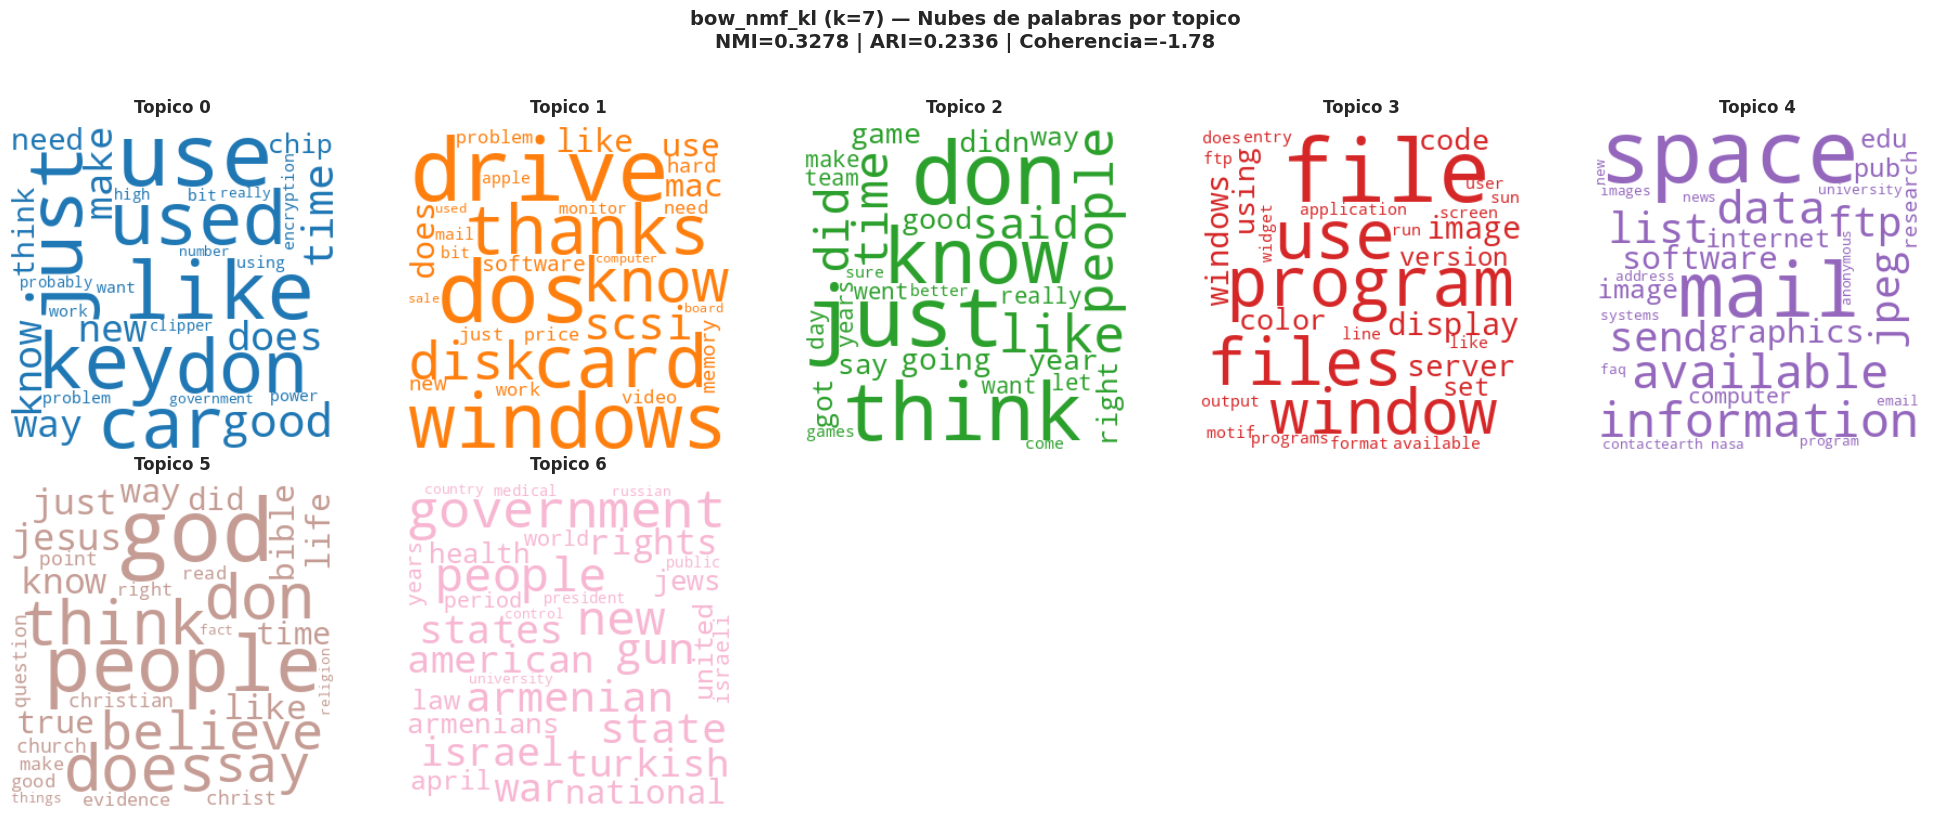

--- k=7 completado ---


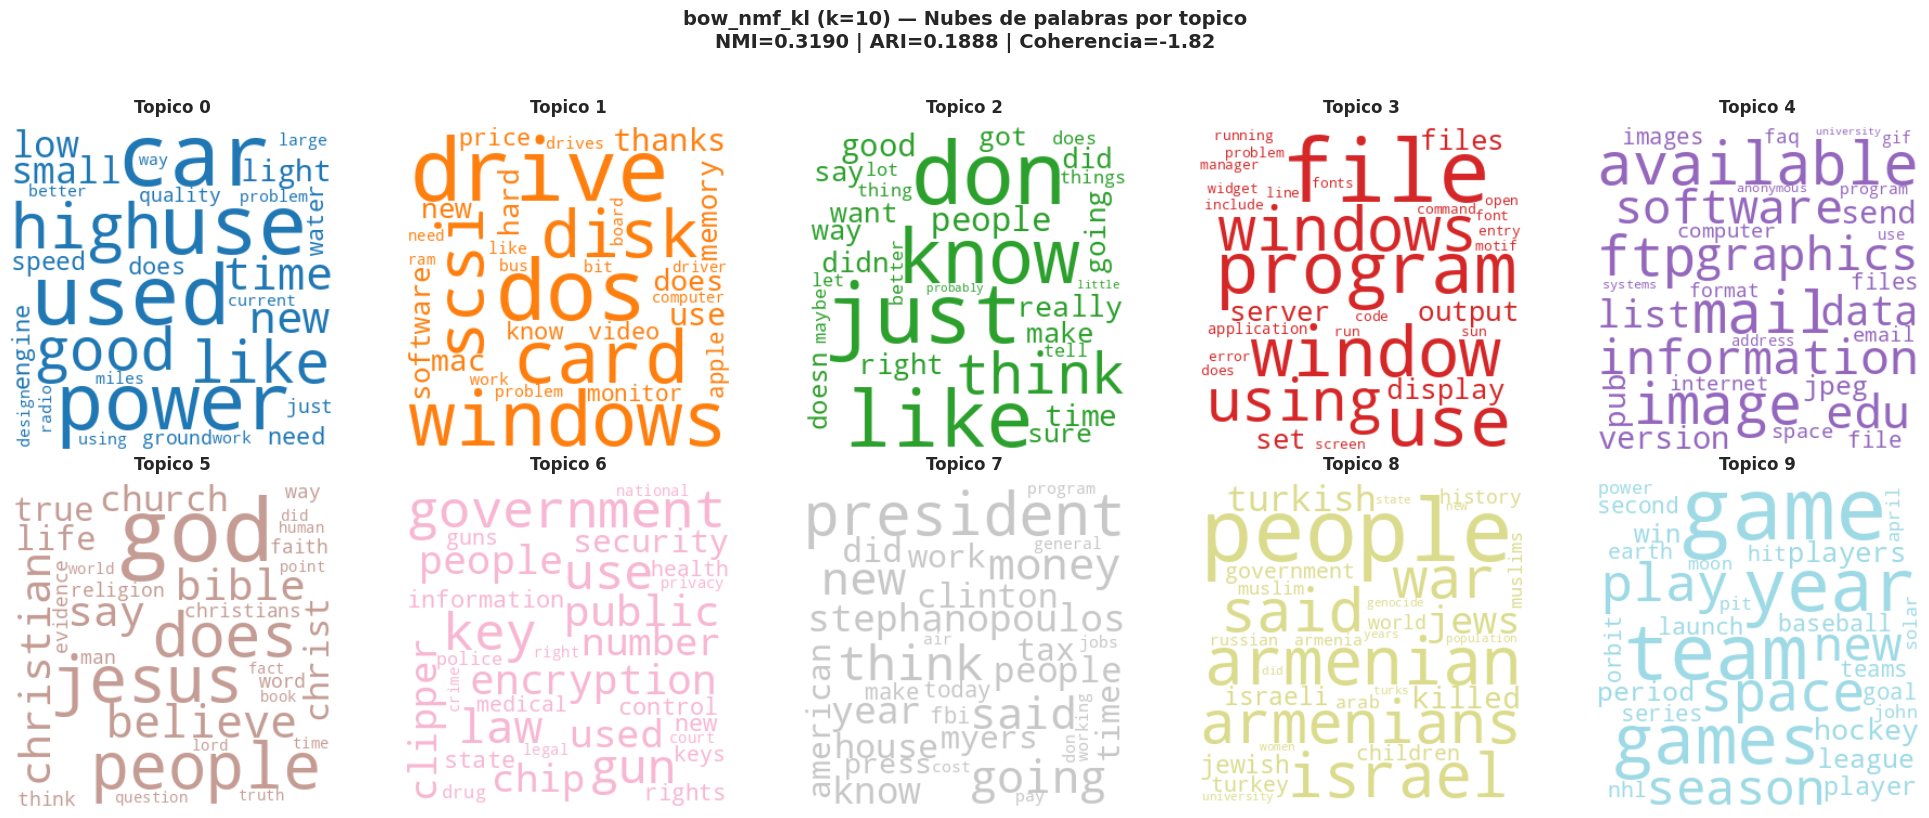

--- k=10 completado ---


In [18]:
# ============================================================
# Nubes de palabras para k=7 y k=10 (mejor modelo: bow_nmf_kl)
# Etiquetas: parent_label (comp, rec, sci, talk, ...)
# ============================================================

from wordcloud import WordCloud
import numpy as np

best_model_name = best_by_model.loc[best_by_model["nmi"].idxmax(), "model"]
best_row_10 = best_by_model[best_by_model["model"] == best_model_name].iloc[0]
best_row_7 = results_df[(results_df["model"] == best_model_name) & (results_df["k"] == 7)].iloc[0]

print(f"Mejor modelo: {best_model_name}")
print(f"k=7 (padres): NMI={best_row_7['nmi']:.4f} | ARI={best_row_7['ari']:.4f}")
print(f"k=10: NMI={best_row_10['nmi']:.4f} | ARI={best_row_10['ari']:.4f}")

# Config para bow_nmf_kl
bow_cfg = configs[1]
k_values_to_show = [7, 10]

# Paleta de colores por topico
import matplotlib.cm as cm
palette = cm.tab20(np.linspace(0, 1, max(k_values_to_show)))

# Mascara circular
def circular_mask(size=300, radius=0.45):
    y, x = np.ogrid[:size, :size]
    center = size // 2
    return (x - center)**2 + (y - center)**2 <= (radius * size)**2

mask = circular_mask(300, radius=0.45)

# Para cada k, generar wordcloud
for k_val in k_values_to_show:
    # Re-ajustar modelo para este k
    from sklearn.decomposition import NMF
    model_k = NMF(
        n_components=k_val,
        init="nndsvda",
        random_state=random_state,
        max_iter=800,
        solver=bow_cfg["solver"],
        beta_loss=bow_cfg["beta_loss"],
        alpha_W=bow_cfg["alpha"],
        alpha_H=bow_cfg["alpha"],
        l1_ratio=bow_cfg["l1_ratio"],
    )
    W_k = model_k.fit_transform(bow_cfg["X"])
    H_k = model_k.components_
    feature_names_k = bow_cfg["feature_names"]
    
    # Asignaciones de documentos para este k
    best_assign_k = assign_df[(assign_df["model"] == best_model_name) & (assign_df["k"] == k_val)].copy()
    
    n_topics = k_val
    cols_wc = 5
    rows_wc = (n_topics + cols_wc - 1) // cols_wc
    
    fig_wc, axes_wc = plt.subplots(rows_wc, cols_wc, figsize=(20, 4 * rows_wc))
    axes_wc = axes_wc.ravel()
    
    for topic_id in range(n_topics):
        ax = axes_wc[topic_id]
        
        weights = H_k[topic_id].copy()
        top_idx = np.argsort(weights)[::-1][:30]
        terms = feature_names_k[top_idx]
        wts = weights[top_idx]
        
        valid = terms != "emptydoc"
        terms = terms[valid]
        wts = wts[valid]
        
        if len(terms) == 0:
            ax.text(0.5, 0.5, "Sin terminos", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue
        
        wts_norm = 10 + (wts / wts.max()) * 70
        wc_dict = dict(zip(terms, wts_norm))
        
        topic_color_rgb = tuple(int(c * 255) for c in palette[topic_id][:3])
        
        wc = WordCloud(
            width=400, height=400, mask=mask,
            background_color="white", max_words=30,
            random_state=42,
            color_func=lambda *args, **kwargs: topic_color_rgb,
            min_font_size=8, max_font_size=80,
            font_step=1, relative_scaling=0.5,
        )
        
        wc.generate_from_frequencies(wc_dict)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"Topico {topic_id}", fontsize=12, fontweight="bold", pad=10)
        ax.axis("off")
    
    for i in range(n_topics, len(axes_wc)):
        axes_wc[i].axis("off")
    
    # Metricas del modelo
    row_k = results_df[(results_df["model"] == best_model_name) & (results_df["k"] == k_val)].iloc[0]
    fig_wc.suptitle(f"{best_model_name} (k={k_val}) — Nubes de palabras por topico\nNMI={row_k['nmi']:.4f} | ARI={row_k['ari']:.4f} | Coherencia={row_k['coherence_umass']:.2f}",
                    fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig_wc.savefig(FIGURES_DIR / f"wordclouds_parent_{best_model_name}_k{k_val}.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"--- k={k_val} completado ---")


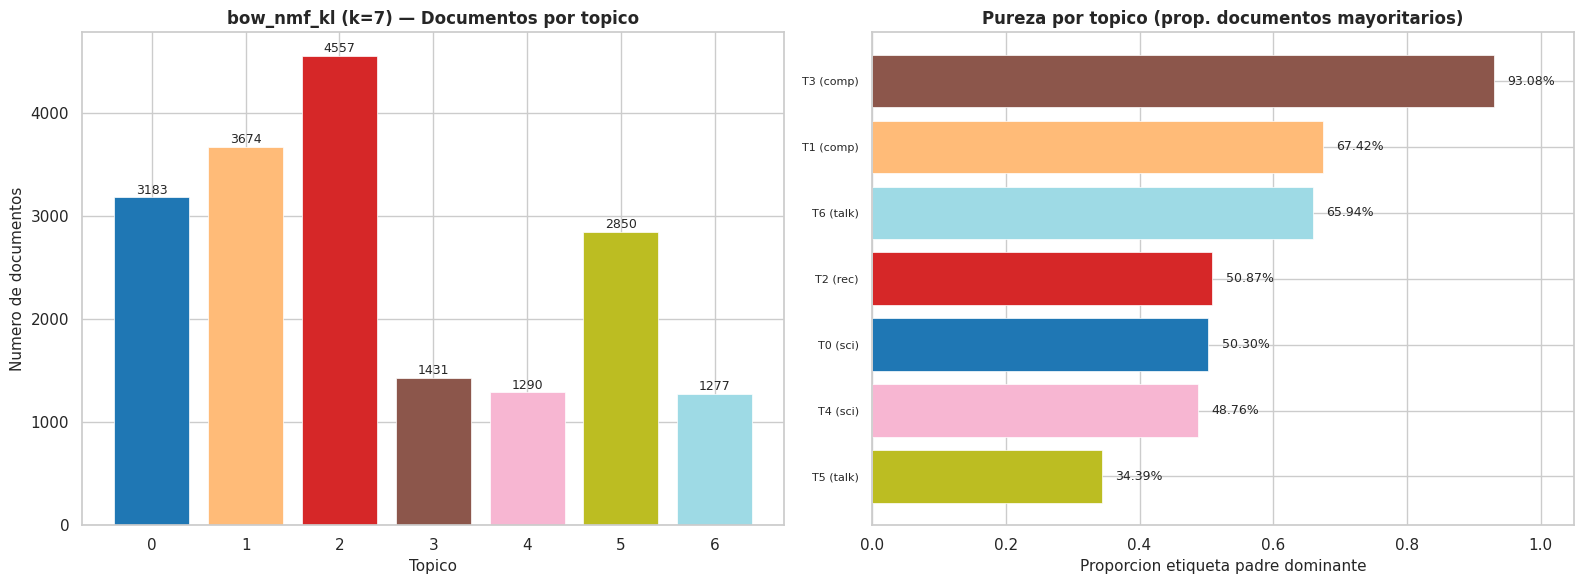

--- Distribucion k=7 completado ---


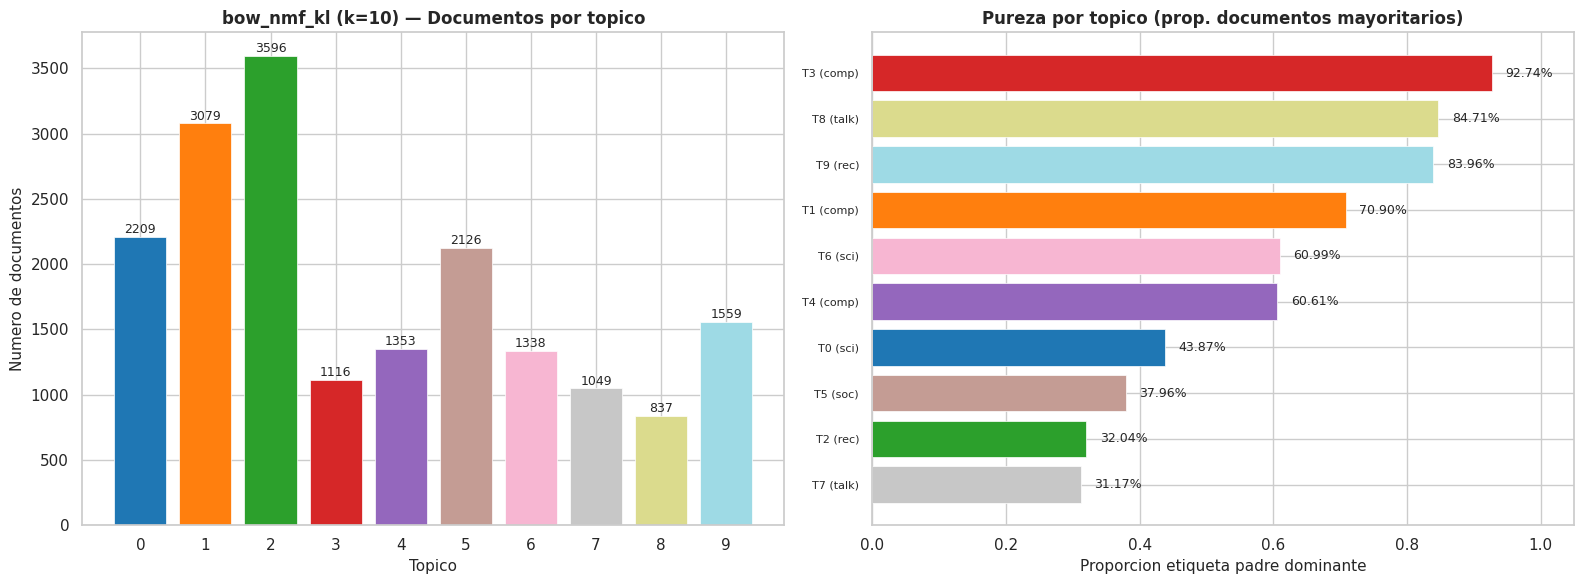

--- Distribucion k=10 completado ---


In [19]:
# ============================================================
# Distribucion de documentos para k=7 y k=10 (etiquetas PADRE)
# ============================================================

for k_val in k_values_to_show:
    best_assign_k = assign_df[(assign_df["model"] == best_model_name) & (assign_df["k"] == k_val)].copy()
    n_topics = k_val
    palette_k = plt.cm.tab20(np.linspace(0, 1, n_topics))
    
    fig_dist, axes_dist = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Distribucion de documentos por topico
    topic_counts = best_assign_k["topic"].value_counts().sort_index()
    bars = axes_dist[0].bar(range(n_topics), topic_counts.values, color=palette_k, edgecolor="white", linewidth=0.5)
    axes_dist[0].set_xlabel("Topico", fontsize=11)
    axes_dist[0].set_ylabel("Numero de documentos", fontsize=11)
    axes_dist[0].set_title(f"{best_model_name} (k={k_val}) — Documentos por topico", fontsize=12, fontweight="bold")
    for bar, cnt in zip(bars, topic_counts.values):
        axes_dist[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                        f"{cnt}", ha="center", va="bottom", fontsize=9)
    axes_dist[0].set_xticks(range(n_topics))
    
    # 2. barras horizontales: topico x proporcion de etiqueta padre dominante
    bar_data = []
    for t in range(n_topics):
        label_dist = best_assign_k[best_assign_k["topic"] == t]["label_parent"].value_counts(normalize=True)
        dominant = label_dist.index[0] if len(label_dist) > 0 else ""
        bar_data.append({
            "topic": t,
            "dominant_label": dominant,
            "prop": label_dist.iloc[0] if len(label_dist) > 0 else 0,
        })
    bar_df = pd.DataFrame(bar_data).sort_values("prop")
    
    colors_bar = [palette_k[t] for t in bar_df["topic"]]
    axes_dist[1].barh(range(len(bar_df)), bar_df["prop"], color=colors_bar, edgecolor="white", linewidth=0.5)
    axes_dist[1].set_yticks(range(len(bar_df)))
    axes_dist[1].set_yticklabels([f"T{t} ({l})" for t, l in zip(bar_df["topic"], bar_df["dominant_label"])], fontsize=8)
    axes_dist[1].set_xlabel("Proporcion etiqueta padre dominante", fontsize=11)
    axes_dist[1].set_title("Pureza por topico (prop. documentos mayoritarios)", fontsize=12, fontweight="bold")
    axes_dist[1].set_xlim(0, 1.05)
    for i, (_, r) in enumerate(bar_df.iterrows()):
        axes_dist[1].text(r["prop"] + 0.02, i, f"{r['prop']:.2%}", va="center", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"topic_distribution_parent_{best_model_name}_k{k_val}.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"--- Distribucion k={k_val} completado ---")


## Notas metodologicas

- La coherencia UMass y la diversidad de terminos solo aplican directamente a modelos basados en bag-of-words/TF-IDF.
- Se ha eliminado NMF sobre embeddings porque pierde la interpretabilidad textual del topic modeling.
- La comparacion entre TF-IDF (Frobenius) y BoW (KL divergence) se evalua con metricas externas (NMI/ARI) y analisis cualitativo.
- **Etiquetas padre**: Se extraen de los labels originales (ej: `comp.graphics` -> `comp`) para analizar la estructura de topics a nivel de categoria.
- **k=7**: coincide con el numero de categorias padre (comp, rec, sci, talk, soc, misc, alt).
- **k=10**: mejor NMI, pero puede estar dividiendo categorias padre en subtopics.
